In [1]:
import os
device = "cuda"
os.environ["DIGNN_ENV"] = device

import sys
sys.path.append('../..')

from DIGNN.data import AtomsData, ase2AtomsData
from DIGNN.utils import AtomIndexMapper, plot_comparison
from DIGNN.pl import DataModule, TrainModule_FF, TrainModule
from DIGNN.nn import models as dgm

import time
import random
import torch
import numpy as np
import pytorch_lightning as pl
from ase.build import molecule

e:\anaconda3\envs\tys\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
W0308 20:03:14.938000 33156 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


In [2]:
hyperparams = {"pml_rcut": 2.0, "pml_mnn": 12, "iml_rcut": 4.0, "iml_mnn": 16}
DIGNN_feat_dim = {'atom_dim': 64, 'bond_dim': 64, 'ang_dim': 32, 'dih_dim': 16}

In [3]:
H2O2 = molecule('H2O2')
H2O2.arrays['energy'] = np.array([0.0])
H2O2.arrays['force'] = np.zeros_like(H2O2.positions)
H2O2.arrays['formation'] = np.array([1.0])
atomsdata = [ase2AtomsData(H2O2, check_rcut=hyperparams["pml_rcut"], properties=['energy', 'force', 'formation']) for _ in range(100)]

CH4 = molecule('CH4')
CH4.arrays['energy'] = np.array([0.0])
CH4.arrays['force'] = np.zeros_like(CH4.positions)
CH4.arrays['formation'] = np.array([1.0])
atomsdata += [ase2AtomsData(CH4, check_rcut=hyperparams["pml_rcut"], properties=['energy', 'force', 'formation']) for _ in range(100)]

C6H6 = molecule('C6H6')
C6H6.arrays['energy'] = np.array([0.0])
C6H6.arrays['force'] = np.zeros_like(C6H6.positions)
C6H6.arrays['formation'] = np.array([1.0])
atomsdata += [ase2AtomsData(C6H6, check_rcut=hyperparams["pml_rcut"], properties=['energy', 'force', 'formation']) for _ in range(100)]

random.shuffle(atomsdata)

## 性质训练测试

In [4]:
data = DataModule(atomsdata, 
                    **hyperparams,
                    test_size=0.2, val_size=0.1,
                    batch_size=8, num_workers=1, store_device='cpu',
                    mapper=AtomIndexMapper(),
                    return_type='cplt',
                    )
data.setup()  # 建议将预处理和训练分开，即提前setup

updating geo: 100%|██████████| 8/8 [00:00<00:00, 472.45batch/s]


In [5]:
model = dgm.DIGNN(encoder=dgm.Encoder(num_species=data.mapper.num_embeddings,
                                            **DIGNN_feat_dim,
                                            pml_rcut=hyperparams["pml_rcut"]+0.2,
                                            bondI_dim=DIGNN_feat_dim['bond_dim'],
                                            iml_rcut=hyperparams["iml_rcut"]+0.2),
                processor=dgm.GCN_Processor(**DIGNN_feat_dim,
                                            pml=1,
                                            iml=4,
                                            residual=True,
                                            dropout=0.0,
                                            bondI_dim=DIGNN_feat_dim['bond_dim'],
                                            init_nn_layer=0,
                                            ), 
                decoder=dgm.Decoder(dim=[DIGNN_feat_dim['atom_dim'],64,1], 
                                    reduce_method='mean', 
                                    dropout=0.0),
                global_processor=dgm.modules.processor_components.Global_node_nn(
                                    atom_dim=DIGNN_feat_dim['atom_dim'],
                                    bond_dim=DIGNN_feat_dim['bond_dim'],
                                    global_node_num=6,
                                    proj_hid_dim=[128,128],
                                    layer_num=4, #iml
                                    residual=True,
                                    )
                ).to(device)
model.processor.lcp.global_processor.cuda()

Global_node_nn(
  (proj_mlp_atom): Sequential(
    (0): MLP(dims=[1, 128, 128, 6], act=SiLU())
    (1): LayerNorm((64, 6), eps=1e-05, elementwise_affine=True)
  )
  (proj_mlp_bond): Sequential(
    (0): MLP(dims=[64, 128, 128, 64], act=SiLU())
    (1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  )
  (global_atm_bnd): ModuleList(
    (0-3): 4 x GatedGCN()
  )
)

In [ ]:

from DIGNN.nn.utils import RBFLayer
angle_rbf = RBFLayer(start=-1, end=1, num_gaussians=8, if_decay=False)

In [55]:
test = torch.arange(-torch.pi,torch.pi,0.1).float().unsqueeze(1)
results = rbf(test).detach().numpy()


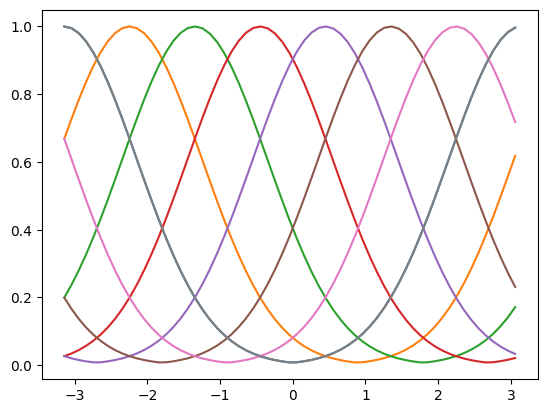

In [56]:
from matplotlib import pyplot as plt

plt.plot(test.numpy(), results)
plt.show()

In [54]:
from torch import nn, Tensor
import torch
class RBFLayer(nn.Module):
    def __init__(self,
                 start=0.0,
                 end=10.0,
                 periodic=None,
                 num_gaussians=100,
                 if_decay=False
                 ):
        super(RBFLayer, self).__init__()
        self.start = start
        self.end = end
        self.if_decay = if_decay
        self.period = periodic
        
        mu = torch.linspace(start, end, num_gaussians).float()
        sigma = torch.ones(num_gaussians).float()
        self.mu = torch.nn.Parameter(mu.view(-1, 1)) # 转为列向量
        # self.register_buffer("mu", mu.view(-1, 1)) # 固定mu不作为参数修改
        self.sigma = torch.nn.Parameter(sigma)  # 作为参数学习
    
    def periodic_distance(self, x, mu):
        """计算周期性距离，考虑角度的周期性"""
        # 计算绝对差
        diff = torch.abs(x - mu)
        # 考虑周期性：min(|x-mu|, period - |x-mu|)
        periodic_diff = torch.min(diff, self.period - diff)
        return periodic_diff
        
    def forward(self, x):
        # 高斯 RBF 的公式: exp(-||x - mu||^2 / (2 * sigma^2))
        if self.period is not None:
            dist = self.periodic_distance(x, self.mu.T)
        else:
            dist = x - self.mu.T
        gaussian = torch.exp(-torch.pow(dist, 2) / (2 * self.sigma ** 2))
        if self.if_decay: return gaussian * self.decay(x)
        return gaussian
    
rbf = RBFLayer(start=-torch.pi, end=torch.pi, num_gaussians=8, if_decay=False, periodic=2*torch.pi)


In [ ]:
max_epoch = 5

train_module = TrainModule(model, 
                           compile_model=False, # 开启编译, 速度更快
                           lr=1e-3,
                           prop='formation',
                           adamw_weight_decay=1e-2,
                           adamw_betas=(0.9, 0.999),
                           onecycle_total_steps=max_epoch*len(data.train_dataloader()), 
                           onecycle_final_div_factor=1e+5,
                           empty_cache_every_epoch=True,
                           )
trainer = pl.Trainer(max_epochs=max_epoch,
                    accelerator="gpu",
                    check_val_every_n_epoch=10,
                    log_every_n_steps=1,
                    precision='16-mixed',
                    benchmark=True,
                    )

In [ ]:
trainer.fit(train_module, train_dataloaders=data.train_dataloader(), val_dataloaders=data.val_dataloader())
# 如果预处理和训练放在一起：
# trainer.fit(datamodule=data)

In [ ]:
trainer.test(train_module, dataloaders=data.test_dataloader())

preds, targets = train_module.test_results.values()
plot_comparison(target=targets, pred=preds)

In [ ]:
train_module.test_results

## 力场训练测试

In [ ]:
data = DataModule(atomsdata, 
                    **hyperparams,
                    test_size=0.2, val_size=0.1,
                    batch_size=8, num_workers=1, store_device='cpu',
                    mapper=AtomIndexMapper(),
                    return_type='basic',
                    )
data.setup()  # 建议将预处理和训练分开，即提前setup


In [ ]:
model = dgm.DIGNN(encoder=dgm.Encoder(num_species=data.mapper.num_embeddings,
                                            **DIGNN_feat_dim,
                                            pml_rcut=hyperparams["pml_rcut"]+0.2,
                                            bondI_dim=DIGNN_feat_dim['bond_dim'],
                                            iml_rcut=hyperparams["iml_rcut"]+0.2),
                processor=dgm.GCN_Processor(**DIGNN_feat_dim,
                                            pml=1,
                                            iml=4,
                                            residual=True,
                                            dropout=0.0,
                                            bondI_dim=DIGNN_feat_dim['bond_dim'],
                                            init_nn_layer=0,
                                            ), 
                decoder=dgm.Decoder(dim=[DIGNN_feat_dim['atom_dim'],64,1], 
                                    reduce_method='sum', 
                                    dropout=0.0),
                global_processor=dgm.modules.processor_components.Global_node_nn(
                                    atom_dim=DIGNN_feat_dim['atom_dim'],
                                    bond_dim=DIGNN_feat_dim['bond_dim'],
                                    global_node_num=6,
                                    proj_hid_dim=[128,128],
                                    layer_num=4, #iml
                                    residual=True,
                                    )
                ).to(device)
model.processor.lcp.global_processor.cuda()

In [ ]:
max_epoch = 5

train_module = TrainModule_FF(model,
                              compile_model=False, # FF训练不开启
                              lr=1e-3,
                              energy_weight=0.1,
                              force_weight=1.0,
                              adamw_weight_decay=1e-2,
                              adamw_betas=(0.9, 0.999),
                              onecycle_total_steps=max_epoch*len(data.train_dataloader()),
                              onecycle_final_div_factor=1e+5,
                              )
trainer = pl.Trainer(max_epochs=max_epoch,
                    accelerator="gpu",
                    check_val_every_n_epoch=10,
                    log_every_n_steps=50,
                    benchmark=True,
                    inference_mode=False,
                    )

In [ ]:
trainer.fit(train_module, train_dataloaders=data.train_dataloader(), val_dataloaders=data.val_dataloader())
# 如果预处理和训练放在一起：
# trainer.fit(datamodule=data)


In [ ]:
trainer.test(train_module, dataloaders=data.test_dataloader())

preds_ene, targets_ene, preds_force, targets_force, atom_num = train_module.test_results.values()
plot_comparison(target=targets_ene, pred=preds_ene, atom_num=atom_num)
# plot_comparison(target=targets_force, pred=preds_force)